In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn import model_selection
from sklearn import metrics
from scipy import stats

df_boston = pd.read_csv("boston.csv")
print(df_boston)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14

In [79]:
# CRIM → 범죄율
# ZN → 대형 주거지 비율
# INDUS → 비소매 상업 지역 비율
# CHAS → 찰스강 더미 변수
# NOX → 일산화질소 농도
# RM → 주택당 평균 방 개수
# AGE → 오래된 주택 비율
# DIS → 직주 근접도
# RAD → 방사형 고속도로 접근성 지수
# TAX → 재산세율
# PTRATIO → 학생-교사 비율
# B → 흑인 인구 비율 지수
# LSTAT → 하위 계층 비율
# MEDV → 주택 가격 중앙값

In [80]:
shapiro_test = stats.shapiro(df_boston)
print(shapiro_test) # pvalue=np.float64(7.348722154426317e-88)

ShapiroResult(statistic=np.float64(0.5189043882319008), pvalue=np.float64(7.348722154426317e-88))


c:\Users\user\.conda\envs\env_ds\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7084.
  res = hypotest_fun_out(*samples, **kwds)


In [81]:
# 결측치 확인
df_boston.info()
df_boston.shape

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


(506, 14)

In [82]:
# 기초통계량 분석
print(df_boston.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

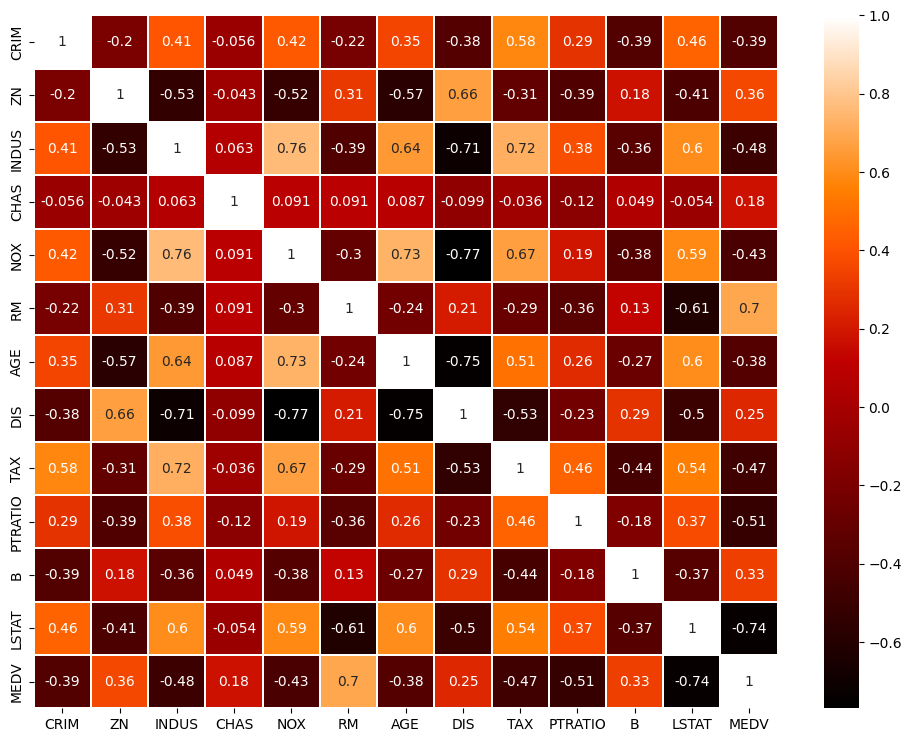

In [83]:
colormap = plt.cm.gist_heat   
plt.figure(figsize=(12,9))


sns.heatmap(df_boston_corr,linewidths=0.2,vmax=1, cmap=colormap, linecolor='white', annot=True)
plt.show()


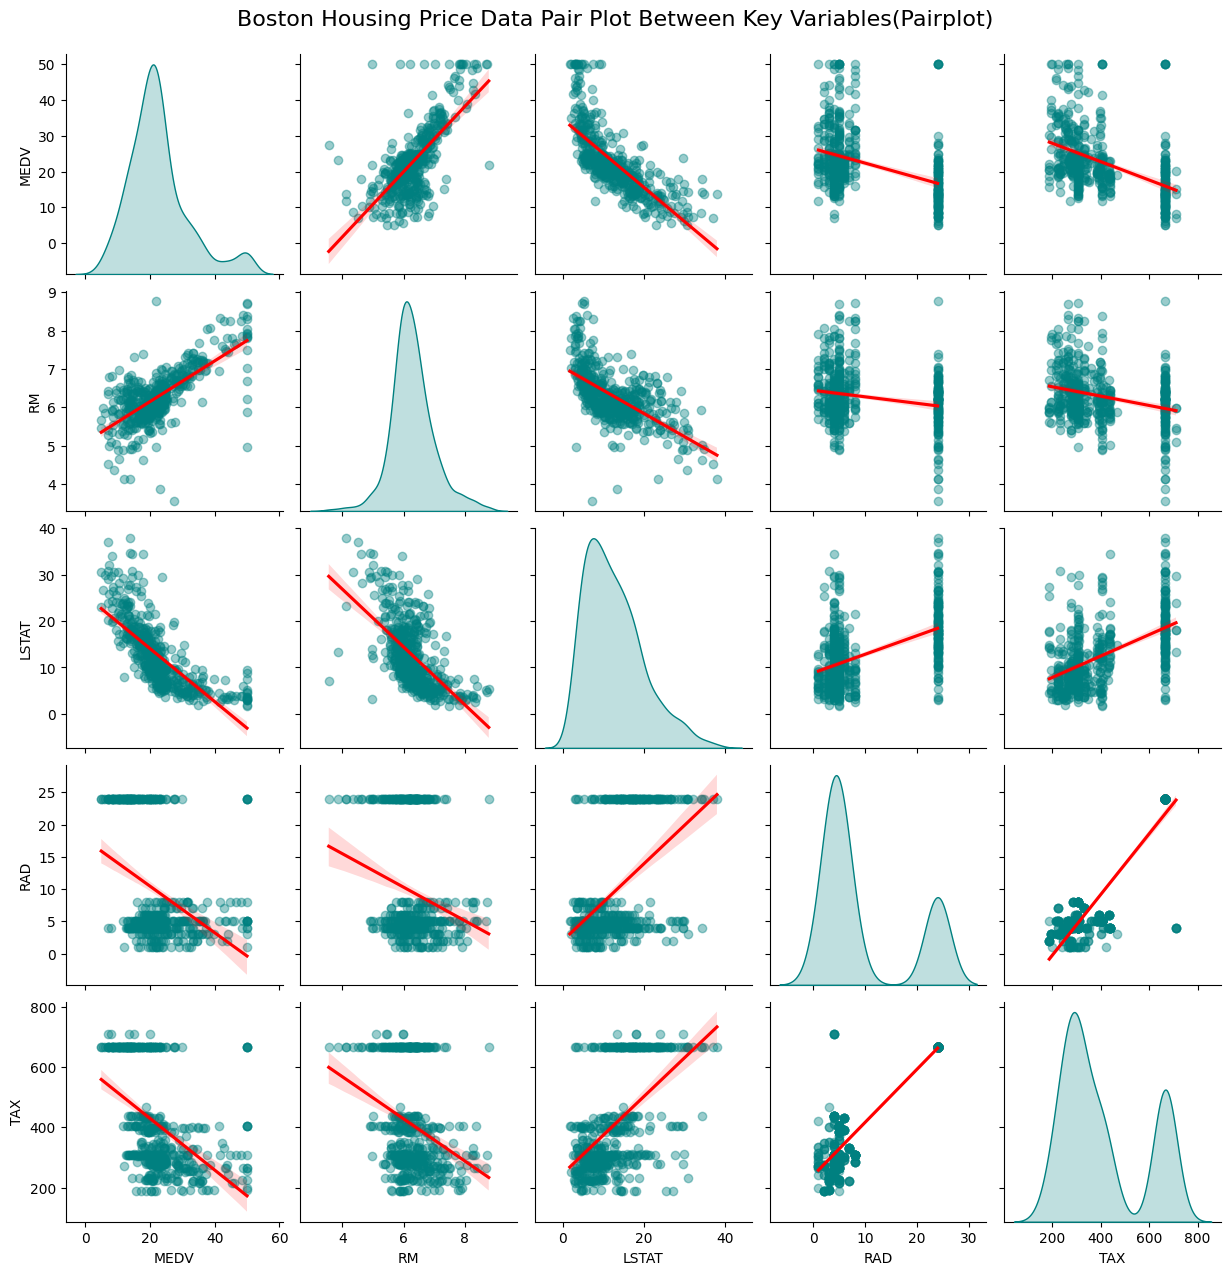

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 14개를 다 넣으면 알아보기 힘들기 때문에 핵심변수들만 추려냄.
selected_columns = ['MEDV', 'RM', 'LSTAT', 'RAD', 'TAX']
df_selected = df_boston[selected_columns]

sns.pairplot(
    df_selected, 
    kind='reg', 
    diag_kind='kde',
    plot_kws={'scatter_kws': {'alpha': 0.4, 'color': 'teal'}, 'line_kws': {'color': 'red'}},
    diag_kws={'color': 'teal'}
)

plt.suptitle("Boston Housing Price Data Pair Plot Between Key Variables(Pairplot)", y=1.02, fontsize=16)
plt.show()

In [85]:
# RAD(고속도로 접근성)과 TAX(재산세율)는 다중공선성 문제를 일으킬 수 있으므로 비교적 다른 변수들과 상관성이 적은 RAD를 삭제.

df_boston.drop(columns=["RAD"],errors="ignore",inplace=True)

print(df_boston)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS    TAX  PTRATIO  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  296.0     15.3   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  242.0     17.8   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  242.0     17.8   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  222.0     18.7   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  222.0     18.7   
..       ...   ...    ...   ...    ...    ...   ...     ...    ...      ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  273.0     21.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  273.0     21.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  273.0     21.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  273.0     21.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  273.0     21.0   

          B  LSTAT  MEDV  
0    396.90   4.98  24.0

count    506.000000
mean       3.613524
std        8.601545
min        0.006320
25%        0.082045
50%        0.256510
75%        3.677083
max       88.976200
Name: CRIM, dtype: float64


<Axes: xlabel='CRIM', ylabel='Count'>

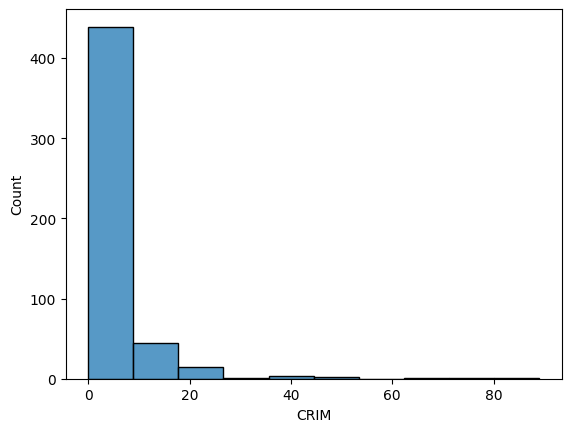

In [86]:
# df_boston["CRIM"].value_counts() 범죄율 단변량 분석

print(
df_boston["CRIM"]
.describe()
)

sns.histplot(
df_boston["CRIM"],
bins=10
)

count    506.000000
mean      11.363636
std       23.322453
min        0.000000
25%        0.000000
50%        0.000000
75%       12.500000
max      100.000000
Name: ZN, dtype: float64


<Axes: xlabel='ZN', ylabel='Count'>

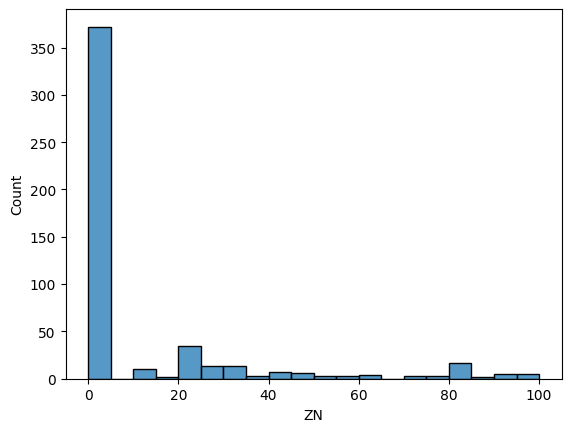

In [87]:
# df_boston["ZN"].value_counts() 대형 주거지 비율 단변량 분석

print(
df_boston["ZN"]
.describe()
)

sns.histplot(
df_boston["ZN"],
bins=20
)

count    506.000000
mean      11.136779
std        6.860353
min        0.460000
25%        5.190000
50%        9.690000
75%       18.100000
max       27.740000
Name: INDUS, dtype: float64


<Axes: xlabel='INDUS', ylabel='Count'>

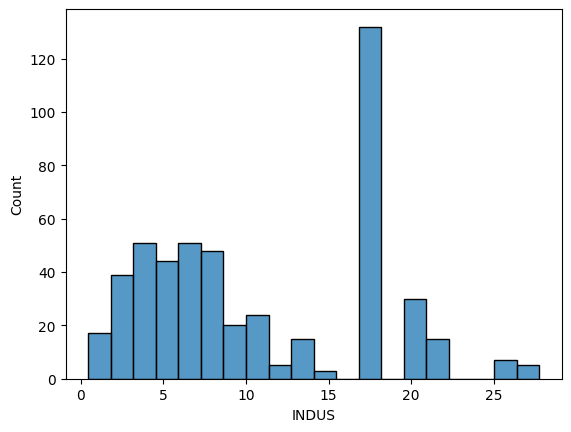

In [88]:
# df_boston["INDUS"].value_counts() 비소매 상업지역 비율 단변량 분석

print(
df_boston["INDUS"]
.describe()
)

sns.histplot(
df_boston["INDUS"],
bins=20
)

빈도수
CHAS
0.0    471
1.0     35
Name: count, dtype: int64

비율(%)
CHAS
0.0    93.08
1.0     6.92
Name: proportion, dtype: float64


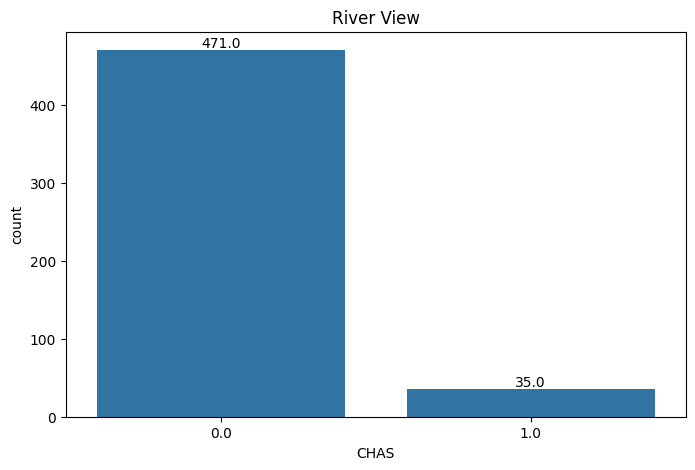

In [89]:
# 강세권 영향 확인
count = (df_boston["CHAS"].value_counts())

print("빈도수")
print(count)

print()

# 비율
ratio = (df_boston["CHAS"].value_counts(normalize=True)*100)

print("비율(%)")
print(ratio.round(2))

# 시각화
plt.figure(
    figsize=(8,5)
)


ax = sns.countplot(
    x="CHAS",
    data=df_boston
)

# 막대 위 수치 출력
for p in ax.patches:
    height = p.get_height()
    
    ax.annotate(
        f"{height}",
        (
            p.get_x()
            +
            p.get_width()/2,
            height
            ),
        ha="center",
        va="bottom"
    )


plt.title(
    "River View"
)

plt.show()

# 0 => 강세권(X)
# 1 => 강세권

count    506.000000
mean       6.284634
std        0.702617
min        3.561000
25%        5.885500
50%        6.208500
75%        6.623500
max        8.780000
Name: RM, dtype: float64


<Axes: xlabel='RM', ylabel='Count'>

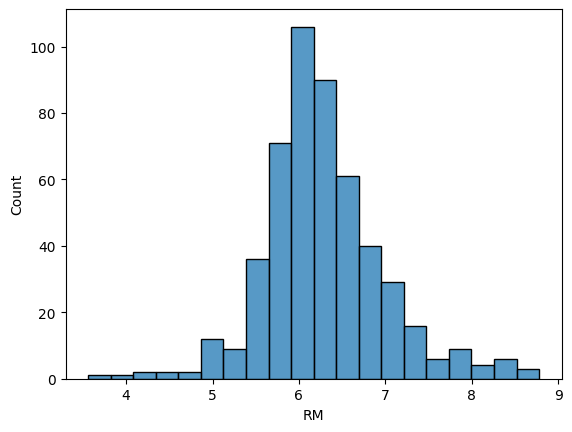

In [90]:
# df_boston["RM"].value_counts() 방 갯수 단변량 분석

print(
df_boston["RM"]
.describe()
)

sns.histplot(
df_boston["RM"],
bins=20
)

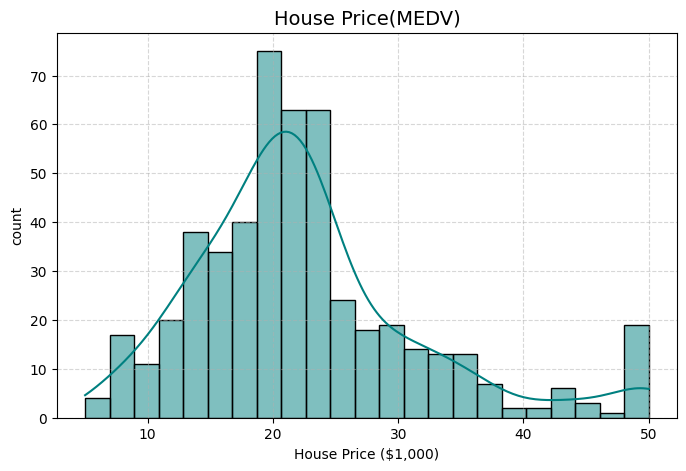

In [91]:
# df_boston["MEDV"].value_counts() 주택 가격 단변량 분석
plt.figure(figsize=(8, 5))
sns.histplot(df_boston['MEDV'], kde=True, color='teal')

plt.title('House Price(MEDV)', fontsize=14)
plt.xlabel('House Price ($1,000)')
plt.ylabel('count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

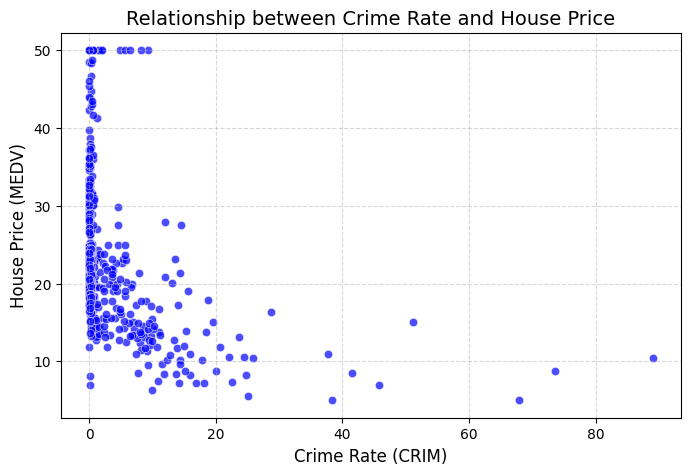

In [92]:
# 이변량 분석
# CRIM ↔ MEDV

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="CRIM", 
    y="MEDV", 
    data=df_boston, 
    alpha=0.7,      
    color="blue"    
)

plt.title("Relationship between Crime Rate and House Price", fontsize=14)
plt.xlabel("Crime Rate (CRIM)", fontsize=12)
plt.ylabel("House Price (MEDV)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# 분석

# CRIM(범죄율)이 낮은 지역에 산점도가 밀접해있음.
# CRIM(범죄율)이 높을수록 MEDV(주택 가격 중앙값)은 떨어져있는 흐름을 보이고 있다.
# CRIM(범죄율)과 MEDV(주택 가격)은 밀접한 관련이 있다고 볼 수 있다.

C:\Users\user\AppData\Local\Temp\ipykernel_23268\3484835144.py:12: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23268\3484835144.py:12: UserWarning: Glyph 51396 (\N{HANGUL SYLLABLE JOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23268\3484835144.py:12: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23268\3484835144.py:12: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23268\3484835144.py:12: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_23268\3484835144.py:12: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(

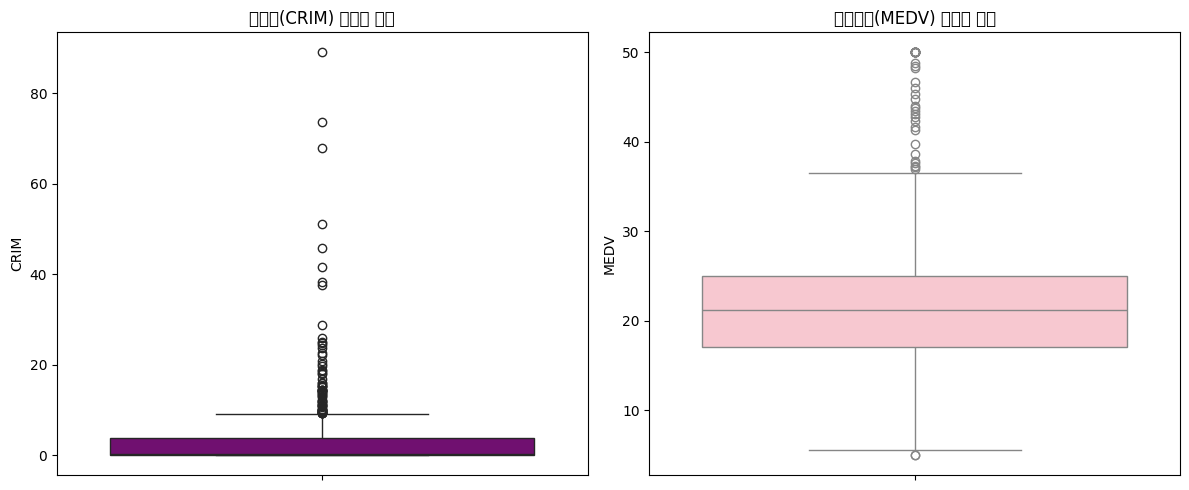

In [93]:
# 범죄율(CRIM)과 주택가격(MEDV)의 이상치 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_boston['CRIM'], color='purple')
plt.title('범죄율(CRIM) 이상치 확인')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_boston['MEDV'], color='pink')
plt.title('주택가격(MEDV) 이상치 확인')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_23268\3532164521.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


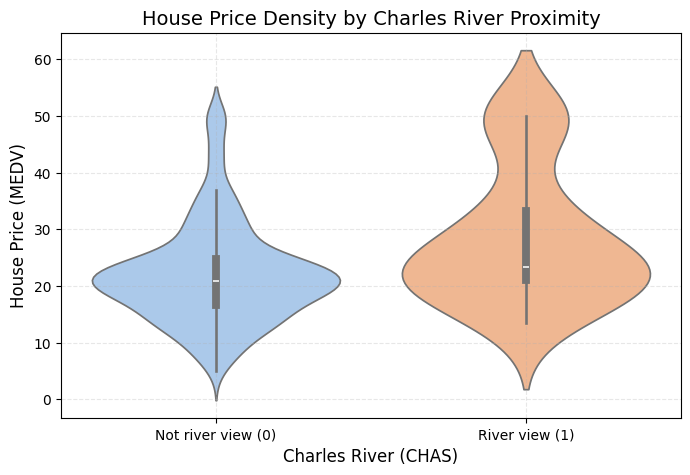

In [94]:
# CHAS ↔ MEDV
# 강세권과 주택 가격은 연관성이 있는 가?

plt.figure(figsize=(8, 5))

# sns.violinplot으로 데이터의 부피(밀도)까지 시각화
sns.violinplot(
    x="CHAS", 
    y="MEDV", 
    data=df_boston,
    palette="pastel"
)

plt.xticks([0, 1], ['Not river view (0)', 'River view (1)'])
plt.title("House Price Density by Charles River Proximity", fontsize=14)
plt.xlabel("Charles River (CHAS)", fontsize=12)
plt.ylabel("House Price (MEDV)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

# 분석

# 찰스 강 주변의 위치(강세권)가 그렇지 않은 위치보다 전체적으로 위쪽으로 치우쳐있다.
# 찰스 강 조망 여부는 주택 가격 상승에 유의미한 영향(긍정적)을 미친다고 볼 수 있다.

Text(0, 0.5, 'House Price')

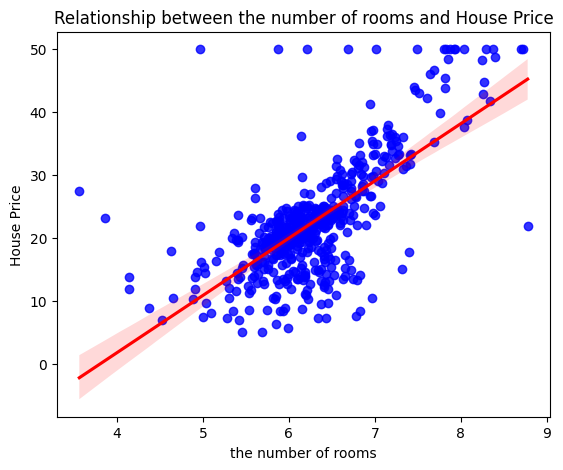

In [95]:
# 방 개수 와 주택 가격은 연관성이 있는가?

plt.figure(figsize=(14, 5))

# [방 개수 vs 주택가격]
plt.subplot(1, 2, 1)
sns.regplot(data=df_boston, x='RM', y='MEDV', color='blue', line_kws={'color':'red'})
plt.title('Relationship between the number of rooms and House Price', fontsize=12)
plt.xlabel('the number of rooms')
plt.ylabel('House Price')



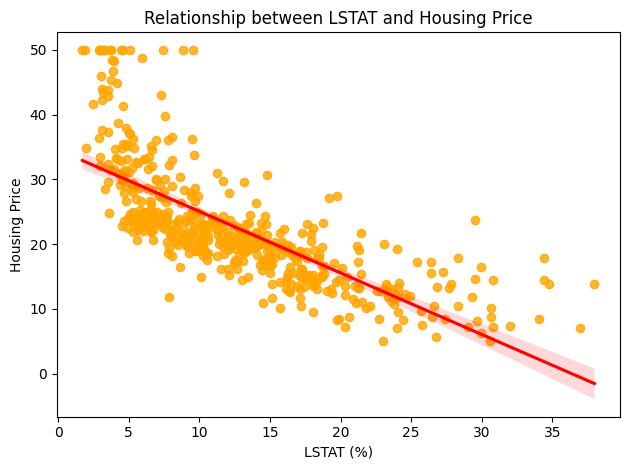

In [96]:
# [하위계층 비율 vs 주택가격]
plt.subplot(1, 1, 1)
sns.regplot(data=df_boston, x='LSTAT', y='MEDV', color='orange', line_kws={'color':'red'})
plt.title('Relationship between LSTAT and Housing Price', fontsize=12)
plt.xlabel('LSTAT (%)')
plt.ylabel('Housing Price')

plt.tight_layout()
plt.show()

# "방 개수가 많을수록 주택가격은 선형적으로 증가하며, 하위계층 비율이 높을수록 주택가격은 완만한 곡선을 그리며 하락하는 경향을 보인다."

In [97]:
# =========================================================================
# [최종 EDA 결론 및 머신러닝 데이터 전처리 방향성]
# 1. 타겟 변수인 주택가격(MEDV)은 전반적으로 정규분포를 따르나, 50달러 선에 데이터가 몰려있어 
#    모델 학습 시 해당 데이터의 제외 여부를 고민할 필요가 있음.
# 2. 히트맵 및 VIF 분석 결과, TAX(재산세)와 RAD(고속도로 접근성) 간의 강력한 다중공선성이 확인되므로, 
#    예측 모델링 시 RAD 변수를 제거하거나 Ridge/Lasso 같은 규제 모델을 사용하는 것이 적합함.
# 3. 주택가격 예측에 가장 크게 기여하는 변수는 RM(방 개수)과 LSTAT(하위계층 비율)이 될 것으로 예상됨.
# =========================================================================